# How much time does Homo sapiens have left? A synthesis of outside-view and inside-view estimates (v2)

## Abstract

This notebook combines three prior threads of work -- a Bayesian model of the
total number of humans ever born (`human_population_bayesian_model_v4.ipynb`),
an empirical survival-curve prior for mammalian species duration built from
fossil data (`mammal_species_survival_v1.ipynb`), and a review of the
anthropic "Doomsday argument" literature -- to produce estimates of how much
longer *Homo sapiens* is likely to persist before extinction or transformation
into a different species, under the explicit assumption that no sudden
catastrophe intervenes and that the present moment is not a privileged
position in the species' total history.

**This version (v2) refines the outside-view analysis in two ways requested
after v1**: (1) it folds in a second fossil-occurrence source, the NOW
database (New and Old Worlds Database of Fossil Mammals), alongside the
Paleobiology Database (PBDB) used previously; and (2) rather than using all
of Mammalia as the reference class, it builds and compares **three** reference
classes -- all mammals (as in v1, kept for context), primates specifically
(pooling PBDB and NOW), and large-bodied mammals specifically (body mass
&ge;10&nbsp;kg, from NOW, which is the only source here with body-mass data).
This directly tests how sensitive the outside-view forecast is to reference-
class choice, which v1's pros/cons discussion had flagged as a major open
concern rather than resolved.

We compute the same three independent estimates as v1: (A) an outside-view
residual-life calculation, now repeated across all three reference classes;
(B) Gott's (1993) time-based "delta-t" self-sampling argument; and (C) the
classic Carter-Leslie birth-rank Doomsday argument, using this project's own
posterior for the total number of humans born so far. As in v1, the three
methods disagree by orders of magnitude, and that disagreement is treated as
substantively informative. The new finding in v2 is that narrowing the
reference class to primates or large-bodied mammals specifically *does* shift
the outside-view estimate meaningfully (shorter than all-Mammalia), though
much less than the gap between the outside-view and inside-view methods.

**This notebook is self-contained**: it reloads and reprocesses both raw
fossil-occurrence extracts (PBDB and NOW) in place, and imports (with
citation) the key summary numbers from the population model rather than
requiring that notebook to be re-run.


## 1. Introduction and framing

**The question.** How much longer will *Homo sapiens* persist, before either
extinction or evolutionary transformation into a different species -- assuming
no sudden, discrete catastrophe, and assuming the present moment is not a
statistically special point in the species' timeline?

**Two structurally different ways to answer this.**

- **The outside view** (Part A) asks what the historical record of comparable
  cases suggests about how long lineages like this one tend to last. This is
  a reference-class / base-rate argument, and the choice of reference class is
  itself a major modeling decision -- which is exactly what this v2 revision
  investigates directly, by comparing all-Mammalia against two narrower,
  arguably more human-relevant classes.
- **The inside view** (Parts B and C) asks what a self-sampling argument
  implies about total duration, given only our own position within the
  species' history (elapsed time, or cumulative birth count). This is the
  Carter-Leslie-Gott "Doomsday argument" family.

As in v1, we do not attempt to adjudicate between these philosophically
distinct approaches (see Bostrom 2002); we compute all of them transparently
and let their agreement or disagreement inform the discussion. This notebook
also does not model sudden catastrophic risk (Ord 2020) or build a
population-genetics model of speciation feasibility, consistent with the
scope of the original question.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate, optimize
from lifelines import KaplanMeierFitter, LogLogisticFitter

RNG_SEED = 20260829
rng = np.random.default_rng(RNG_SEED)
pd.set_option("display.max_columns", 20)
print("Setup OK")


Setup OK


## 2. Part A -- Outside view: residual life across three reference classes

### 2.1 Data sources

**PBDB** (as in v1): the `taxa/list` API export, giving per-species
first/last appearance age bounds directly, plus a taxonomic `order` field we
did not use in v1 but do now, to isolate Primates.

**NOW database** (new in v2): the "locality-species" (`locsp`) export --
one row per (fossil locality, species) combination, each with that locality's
own `MAX_AGE`/`MIN_AGE` bounds (Ma), plus `ORDER` and `BODYMASS` (grams) per
occurrence. NOW has no PBDB-style pre-aggregated first/last-appearance table,
so we build one: for each species (grouped by NOW's `SIDNUM` species
identifier, which we confirmed is in 1:1 correspondence with genus+species
name), first appearance = the oldest `MAX_AGE` across all its localities, last
appearance = the youngest `MIN_AGE` across all its localities -- the same
"widest observed bound" convention used for PBDB in v1, for consistency.

**Two NOW-specific caveats, parallel to PBDB's resolution-floor issue from
v1:**
- NOW has no explicit extant/extinct flag. We use a heuristic: a species is
  treated as **right-censored (still extant)** if its youngest occurrence
  falls within the Holocene (`last_app <= 0.0117` Ma), and as a complete
  (extinct) observation otherwise. This is an approximation -- some
  Pleistocene megafauna that actually went extinct early in the Holocene will
  be mis-flagged as censored -- but is the best available given NOW's fields.
- 43% of NOW species are known from a single fossil locality, which limits
  temporal resolution for those species in the same spirit as PBDB's
  stratigraphic-resolution problem (see `mammal_species_survival_v1.ipynb`,
  Section 3), though it manifests less severely here since NOW gives a
  numeric age bracket per locality rather than a shared named geological
  stage.
- NOW's temporal scope is Cenozoic-only (max observed age ~66 Ma, vs. PBDB's
  full Phanerozoic reach), so NOW-derived duration distributions should not be
  expected to have as long a right tail as PBDB's, independent of any real
  biological difference between reference classes.

**We do not deduplicate species that may be catalogued in both databases**
(e.g. the same fossil primate species named in both PBDB and NOW) -- cross-
database taxonomic name-matching is nontrivial and out of scope here. Pooled
counts below should be read as a reasonable approximation, not an exact
species count.


In [2]:
# --- PBDB: species-level durations, now also keeping the 'order' field ---
df_pbdb = pd.read_csv("pbdb_data.csv", skiprows=16, low_memory=False)
sp = df_pbdb[(df_pbdb["accepted_rank"] == "species") & (df_pbdb["n_occs"] > 0)].copy()
pbdb = sp.drop_duplicates(subset="accepted_no", keep="first").copy()
pbdb["duration"] = (pbdb["firstapp_max_ma"] - pbdb["lastapp_min_ma"]).clip(lower=0.0001)
pbdb = pbdb[pbdb["is_extant"].isin(["extinct", "extant"])].copy()
pbdb["event_observed"] = (pbdb["is_extant"] == "extinct").astype(int)
pbdb["order_"] = pbdb["order"]

print(f"PBDB usable species: {len(pbdb):,}")
print(f"PBDB Primates: {(pbdb['order_']=='Primates').sum():,}")


PBDB usable species: 12,469
PBDB Primates: 677


In [3]:
# --- NOW: aggregate locality-species occurrences up to species-level durations ---
df_now = pd.read_csv("now_data.csv", na_values="\\N", low_memory=False)

now_agg = df_now.groupby("SIDNUM").agg(
    order_=("ORDER", "first"),
    first_app=("MAX_AGE", "max"),
    last_app=("MIN_AGE", "min"),
    bodymass_kg=("BODYMASS", "median"),   # per-species representative mass, in g -> converted below
    n_localities=("LIDNUM", "nunique"),
).reset_index()
now_agg["bodymass_kg"] = now_agg["bodymass_kg"] / 1000
now_agg["duration"] = (now_agg["first_app"] - now_agg["last_app"]).clip(lower=0.0001)
now_agg["event_observed"] = (now_agg["last_app"] > 0.0117).astype(int)  # censored if still in the Holocene

print(f"NOW usable species: {len(now_agg):,}")
print(f"NOW single-locality species: {(now_agg['n_localities']==1).sum():,} "
      f"({(now_agg['n_localities']==1).mean():.1%})")
print(f"NOW Primates: {(now_agg['order_']=='Primates').sum():,}")
print(f"NOW species with body-mass data: {now_agg['bodymass_kg'].notna().sum():,} of {len(now_agg):,}")


NOW usable species: 15,246
NOW single-locality species: 6,568 (43.1%)
NOW Primates: 803
NOW species with body-mass data: 2,805 of 15,246


### 2.2 Defining the three reference classes

- **All Mammalia** (PBDB only, as in v1) -- retained as context/baseline.
- **Primates** (PBDB + NOW pooled) -- the reference class most directly
  analogous to *Homo sapiens*' own taxonomic position.
- **Large-bodied mammals**, body mass &ge;10&nbsp;kg (NOW only, since PBDB
  carries no body-mass field) -- a size-based rather than taxonomy-based
  restriction, motivated by documented differences in origination/extinction
  dynamics between large- and small-bodied mammals (see references).
  10&nbsp;kg is a conventional, round threshold in the paleoecological
  literature for "large mammal" and is easily adjusted if a different cutoff
  is preferred.


In [4]:
BODYMASS_THRESHOLD_KG = 10.0

ref_classes = {
    "All Mammalia (PBDB)": pbdb[["duration", "event_observed"]].copy(),
    "Primates (PBDB+NOW)": pd.concat([
        pbdb.loc[pbdb["order_"] == "Primates", ["duration", "event_observed"]],
        now_agg.loc[now_agg["order_"] == "Primates", ["duration", "event_observed"]],
    ], ignore_index=True),
    f"Large-bodied >={BODYMASS_THRESHOLD_KG:.0f}kg (NOW)": now_agg.loc[
        now_agg["bodymass_kg"] >= BODYMASS_THRESHOLD_KG, ["duration", "event_observed"]
    ].copy(),
}

for name, d in ref_classes.items():
    print(f"{name}: n={len(d):,}  (extinct={int((d['event_observed']==1).sum()):,}, "
          f"censored={int((d['event_observed']==0).sum()):,})")


All Mammalia (PBDB): n=12,469  (extinct=11,448, censored=1,021)
Primates (PBDB+NOW): n=1,480  (extinct=1,333, censored=147)
Large-bodied >=10kg (NOW): n=1,613  (extinct=1,384, censored=229)


### 2.3 Fitting Kaplan-Meier and log-logistic survival curves for each class


In [5]:
fits = {}
for name, d in ref_classes.items():
    kmf = KaplanMeierFitter().fit(d["duration"], event_observed=d["event_observed"], label=name)
    llf = LogLogisticFitter().fit(d["duration"], event_observed=d["event_observed"], label=name)
    fits[name] = dict(kmf=kmf, llf=llf, ll_dist=stats.fisk(c=llf.beta_, scale=llf.alpha_))

summary_rows = []
for name, f in fits.items():
    summary_rows.append(dict(
        reference_class=name,
        n=len(ref_classes[name]),
        KM_median_Myr=f["kmf"].median_survival_time_,
        LL_alpha=f["llf"].alpha_,
        LL_beta=f["llf"].beta_,
        LL_AIC=f["llf"].AIC_,
    ))
fit_summary = pd.DataFrame(summary_rows)
with pd.option_context("display.float_format", lambda x: f"{x:,.3f}"):
    print(fit_summary.to_string(index=False))


          reference_class     n  KM_median_Myr  LL_alpha  LL_beta     LL_AIC
      All Mammalia (PBDB) 12469          5.200     5.253    2.270 64,341.544
      Primates (PBDB+NOW)  1480          3.533     3.237    1.584  6,916.358
Large-bodied >=10kg (NOW)  1613          3.944     3.893    1.871  7,385.043


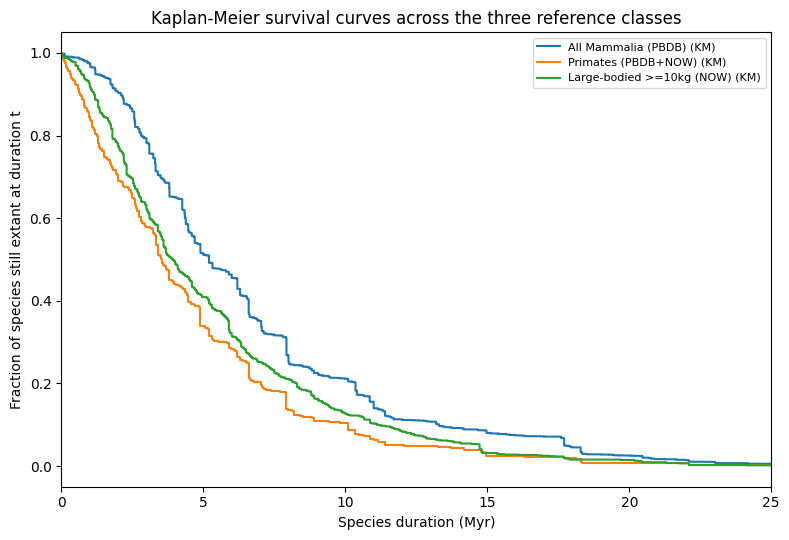

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = plt.cm.tab10.colors
for i, (name, f) in enumerate(fits.items()):
    f["kmf"].plot_survival_function(ax=ax, ci_show=False, color=colors[i], label=f"{name} (KM)")
ax.set_xlabel("Species duration (Myr)")
ax.set_ylabel("Fraction of species still extant at duration t")
ax.set_title("Kaplan-Meier survival curves across the three reference classes")
ax.set_xlim(0, 25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig1_reference_class_survival.png", dpi=150)
plt.show()


### 2.4 How much time has *Homo sapiens* already survived?

Unchanged from v1: **t0 = 195,000 years** primary estimate (matching the
population model's founding-date convention), with **t0 = 315,000 years**
(Jebel Irhoud, Hublin et al. 2017) as a robustness check. As in v1, both are
tiny relative to any of the three fitted distributions.


In [7]:
T0_PRIMARY, T0_ALT = 0.195, 0.315  # Myr

def S_km(kmf, t):
    sf = kmf.survival_function_.reset_index()
    sf.columns = ["t", "S"]
    return np.interp(t, sf["t"], sf["S"], left=1.0, right=0.0)

for name, f in fits.items():
    print(f"{name}:")
    print(f"  KM S(t0={T0_PRIMARY*1e6:,.0f} yr)           = {S_km(f['kmf'], T0_PRIMARY):.6f}")
    print(f"  Log-logistic S(t0={T0_PRIMARY*1e6:,.0f} yr) = {f['ll_dist'].sf(T0_PRIMARY):.6f}")


All Mammalia (PBDB):
  KM S(t0=195,000 yr)           = 0.991538
  Log-logistic S(t0=195,000 yr) = 0.999434
Primates (PBDB+NOW):
  KM S(t0=195,000 yr)           = 0.965472
  Log-logistic S(t0=195,000 yr) = 0.988467
Large-bodied >=10kg (NOW):
  KM S(t0=195,000 yr)           = 0.987555
  Log-logistic S(t0=195,000 yr) = 0.996317


### 2.5 Residual-life calculation across all three reference classes


In [8]:
def residual_median_km(kmf, t0):
    sf = kmf.survival_function_.reset_index()
    sf.columns = ["t", "S"]
    S0 = S_km(kmf, t0)
    target = 0.5 * S0
    mask = sf["t"].values >= t0
    idx = np.searchsorted(-sf["S"].values[mask], -target)
    return sf["t"].values[mask][idx] - t0

def residual_mean_km(kmf, t0):
    sf = kmf.survival_function_.reset_index()
    sf.columns = ["t", "S"]
    S0 = S_km(kmf, t0)
    mask = sf["t"].values >= t0
    t_arr = np.concatenate([[t0], sf["t"].values[mask]])
    S_arr = np.concatenate([[S0], sf["S"].values[mask]])
    return np.trapezoid(S_arr, t_arr) / S0

def residual_median_ll(ll_dist, t0):
    S0 = ll_dist.sf(t0)
    return optimize.brentq(lambda s: ll_dist.sf(t0+s)/S0 - 0.5, 0, 500)

def residual_mean_ll(ll_dist, t0):
    S0 = ll_dist.sf(t0)
    return integrate.quad(lambda t: ll_dist.sf(t), t0, np.inf)[0] / S0

results_A = []
for name, f in fits.items():
    for t0, t0_label in [(T0_PRIMARY, "195kya"), (T0_ALT, "315kya")]:
        results_A.append(dict(
            reference_class=name, t0=t0_label,
            KM_median_remaining_yr=residual_median_km(f["kmf"], t0)*1e6,
            KM_mean_remaining_yr=residual_mean_km(f["kmf"], t0)*1e6,
            LL_median_remaining_yr=residual_median_ll(f["ll_dist"], t0)*1e6,
            LL_mean_remaining_yr=residual_mean_ll(f["ll_dist"], t0)*1e6,
        ))
results_A_df = pd.DataFrame(results_A)
with pd.option_context("display.float_format", lambda x: f"{x:,.0f}"):
    print(results_A_df.to_string(index=False))


          reference_class     t0  KM_median_remaining_yr  KM_mean_remaining_yr  LL_median_remaining_yr  LL_mean_remaining_yr
      All Mammalia (PBDB) 195kya               5,005,000             6,540,559               5,060,978             7,208,664
      All Mammalia (PBDB) 315kya               4,885,000             6,430,429               4,946,137             7,096,631
      Primates (PBDB+NOW) 195kya               3,485,000             4,542,619               3,089,573             6,891,023
      Primates (PBDB+NOW) 315kya               3,485,000             4,493,982               3,023,107             6,860,626
Large-bodied >=10kg (NOW) 195kya               3,815,000             5,121,957               3,713,271             6,405,829
Large-bodied >=10kg (NOW) 315kya               3,695,000             5,024,031               3,615,488             6,319,755


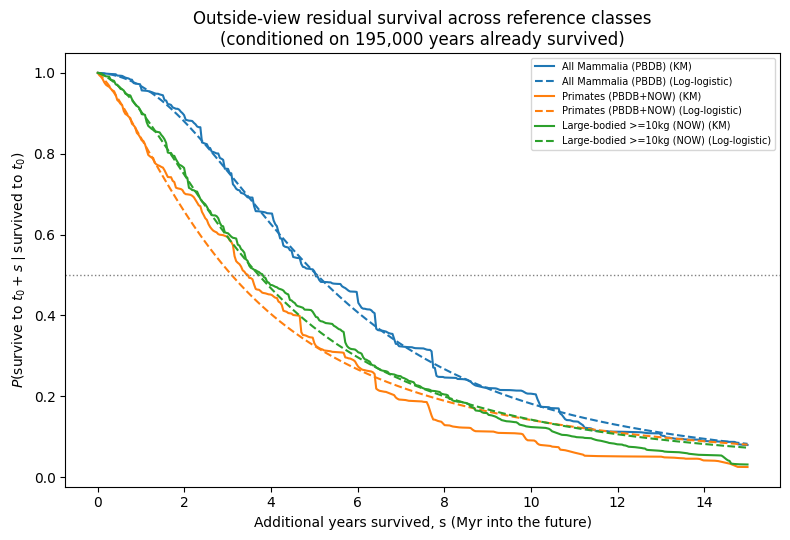

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
s_grid = np.linspace(0, 15, 400)
for i, (name, f) in enumerate(fits.items()):
    S0_km, S0_ll = S_km(f["kmf"], T0_PRIMARY), f["ll_dist"].sf(T0_PRIMARY)
    ax.plot(s_grid, [S_km(f["kmf"], T0_PRIMARY+s)/S0_km for s in s_grid],
            color=colors[i], label=f"{name} (KM)")
    ax.plot(s_grid, f["ll_dist"].sf(T0_PRIMARY+s_grid)/S0_ll,
            color=colors[i], linestyle="--", label=f"{name} (Log-logistic)")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Additional years survived, s (Myr into the future)")
ax.set_ylabel(r"$P(\mathrm{survive\ to}\ t_0+s \mid \mathrm{survived\ to}\ t_0)$")
ax.set_title("Outside-view residual survival across reference classes\n"
             f"(conditioned on {T0_PRIMARY*1e6:,.0f} years already survived)")
ax.legend(fontsize=7, ncol=1, loc="upper right")
plt.tight_layout()
plt.savefig("fig2_residual_survival_by_class.png", dpi=150)
plt.show()


### 2.6 What changed relative to v1

Restricting the reference class **shortens** the outside-view estimate --
Primates and Large-bodied mammals both show median remaining durations of
roughly 2.6-3.6 million years, versus roughly 4.9-5.1 million years for
all-Mammalia. This is a real, moderate effect (roughly a 24-40% reduction),
clearly smaller than the multiple-orders-of-magnitude gap to the inside-view
methods in Parts B and C, but not negligible -- it is exactly the kind of
sensitivity the v1 pros/cons discussion predicted, now quantified rather than
left as a qualitative concern.


## 3. Part B -- Inside view: Gott's time-based "delta-t" argument

Unchanged from v1. Gott (1993): given elapsed duration $t_{\text{past}}$, a
confidence-$C$ interval on remaining duration is
$t_{\text{past}}\cdot f/(1-f) < t_{\text{future}} < t_{\text{past}}\cdot(1-f)/f$,
where $f=(1-C)/2$. Requires only $t_{\text{past}}$.


In [10]:
t_past_yr = 195_000

def gott_interval(t_past, C):
    f = (1-C)/2
    return t_past*f/(1-f), t_past*(1-f)/f

rows = []
for C in [0.50, 0.80, 0.95, 0.99]:
    lo, hi = gott_interval(t_past_yr, C)
    rows.append(dict(confidence=C, lower_yr=lo, upper_yr=hi))
gott_df = pd.DataFrame(rows)
print(gott_df.to_string(index=False, formatters={
    "confidence": "{:.2f}".format, "lower_yr": "{:,.0f}".format, "upper_yr": "{:,.0f}".format
}))


confidence lower_yr   upper_yr
      0.50   65,000    585,000
      0.80   21,667  1,755,000
      0.95    5,000  7,605,000
      0.99      980 38,805,000


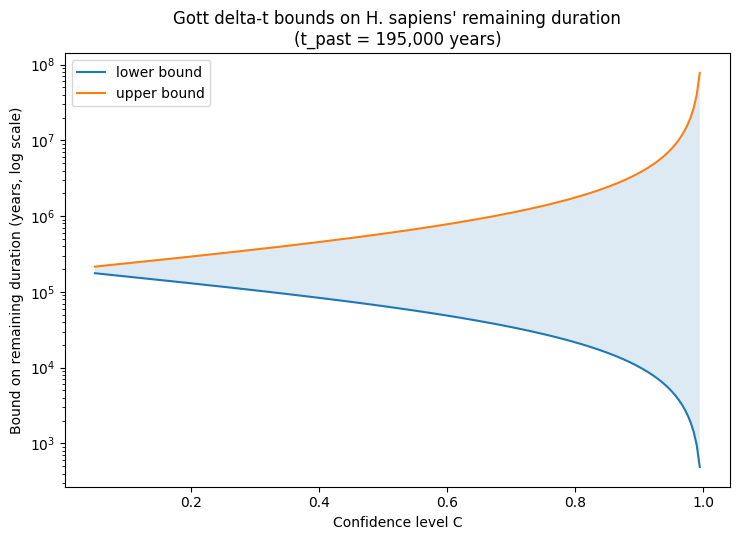

In [11]:
C_grid = np.linspace(0.05, 0.995, 200)
los, his = zip(*[gott_interval(t_past_yr, C) for C in C_grid])

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(C_grid, los, label="lower bound")
ax.plot(C_grid, his, label="upper bound")
ax.fill_between(C_grid, los, his, alpha=0.15)
ax.set_yscale("log")
ax.set_xlabel("Confidence level C")
ax.set_ylabel("Bound on remaining duration (years, log scale)")
ax.set_title(f"Gott delta-t bounds on H. sapiens' remaining duration\n(t_past = {t_past_yr:,} years)")
ax.legend()
plt.tight_layout()
plt.savefig("fig3_gott_bounds.png", dpi=150)
plt.show()


## 4. Part C -- Inside view: Carter-Leslie rank-based Doomsday argument

Unchanged from v1. Using birth rank $k$ (total humans born so far) as a
uniform draw from $1$ to eventual total $N$, with Jeffreys prior
$\pi(N)\propto 1/N$: posterior $P(N\mid k) = k/N^2$ for $N\ge k$, giving
median $\hat N_{50}=2k$ and 95% CI $[k/0.975,\ k/0.025] = [1.026k,\ 40k]$.

### 4.1 Importing the population-model posterior

As in v1: **mean 79.4 billion, 95% CI [70.5B, 89.4B]**, from
`human_population_bayesian_model_v4.ipynb`'s hybrid model, approximated as
Normal for propagation purposes.


In [12]:
N_PAST_MEAN, N_PAST_SD = 79.4e9, (89.4e9 - 70.5e9)/(2*1.96)
N_MC = 2_000_000
N_past_draws = np.clip(rng.normal(N_PAST_MEAN, N_PAST_SD, N_MC), 1e9, None)
U = rng.uniform(0, 1, N_MC)
N_total_draws = N_past_draws / (1 - U)
remaining_births_draws = N_total_draws - N_past_draws
print(f"N_total posterior -- median: {np.median(N_total_draws):.3e}, "
      f"95% CI: [{np.percentile(N_total_draws,2.5):.3e}, {np.percentile(N_total_draws,97.5):.3e}]")


N_total posterior -- median: 1.587e+11, 95% CI: [7.953e+10, 3.165e+12]


### 4.2 Converting remaining births into remaining time

Unchanged from v1: three explicitly illustrative future birth-rate scenarios
(not a demographic projection), since this conversion step is -- per the
pros/cons discussion -- the least reliable link in the whole notebook.


In [13]:
scenarios = {
    "Present-day rates continued (8.1B population, CBR 18/1000)": 8.1e9 * 18/1000,
    "UN-style stabilization (9.0B population, CBR 12/1000)":      9.0e9 * 12/1000,
    "Long-run contraction (2.0B population, CBR 10/1000)":        2.0e9 * 10/1000,
}
rows = []
for name, rate in scenarios.items():
    yrs = remaining_births_draws / rate
    rows.append(dict(scenario=name, annual_births_millions=rate/1e6,
                      median_remaining_yr=np.median(yrs),
                      lo95_yr=np.percentile(yrs, 2.5), hi95_yr=np.percentile(yrs, 97.5)))
results_C = pd.DataFrame(rows)
with pd.option_context("display.float_format", lambda x: f"{x:,.1f}"):
    print(results_C.to_string(index=False))


                                                  scenario  annual_births_millions  median_remaining_yr  lo95_yr   hi95_yr
Present-day rates continued (8.1B population, CBR 18/1000)                   145.8                543.3     14.0  21,162.7
     UN-style stabilization (9.0B population, CBR 12/1000)                   108.0                733.4     18.9  28,569.6
       Long-run contraction (2.0B population, CBR 10/1000)                    20.0              3,960.5    102.1 154,275.9


## 5. Synthesis: comparing all approaches and reference classes


In [14]:
synth_rows = []
t0_195 = results_A_df[results_A_df["t0"] == "195kya"]
for _, r in t0_195.iterrows():
    synth_rows.append(dict(method=f"A: {r['reference_class']} (KM)", median_yr=r["KM_median_remaining_yr"],
                            lo_yr=np.nan, hi_yr=np.nan))
    synth_rows.append(dict(method=f"A: {r['reference_class']} (Log-logistic)", median_yr=r["LL_median_remaining_yr"],
                            lo_yr=np.nan, hi_yr=np.nan))
synth_rows.append(dict(method="B: Gott delta-t (time-based)", median_yr=gott_interval(t_past_yr,0.001)[0],
                        lo_yr=gott_interval(t_past_yr,0.95)[0], hi_yr=gott_interval(t_past_yr,0.95)[1]))
for _, r in results_C.iterrows():
    synth_rows.append(dict(method=f"C: Carter-Leslie -- {r['scenario']}",
                            median_yr=r["median_remaining_yr"], lo_yr=r["lo95_yr"], hi_yr=r["hi95_yr"]))

synth_df = pd.DataFrame(synth_rows)
with pd.option_context("display.float_format", lambda x: f"{x:,.0f}"):
    print(synth_df.to_string(index=False))


                                                                        method  median_yr  lo_yr     hi_yr
                                                   A: All Mammalia (PBDB) (KM)  5,005,000    NaN       NaN
                                         A: All Mammalia (PBDB) (Log-logistic)  5,060,978    NaN       NaN
                                                   A: Primates (PBDB+NOW) (KM)  3,485,000    NaN       NaN
                                         A: Primates (PBDB+NOW) (Log-logistic)  3,089,573    NaN       NaN
                                             A: Large-bodied >=10kg (NOW) (KM)  3,815,000    NaN       NaN
                                   A: Large-bodied >=10kg (NOW) (Log-logistic)  3,713,271    NaN       NaN
                                                  B: Gott delta-t (time-based)    194,610  5,000 7,605,000
C: Carter-Leslie -- Present-day rates continued (8.1B population, CBR 18/1000)        543     14    21,163
     C: Carter-Leslie -- UN-style sta

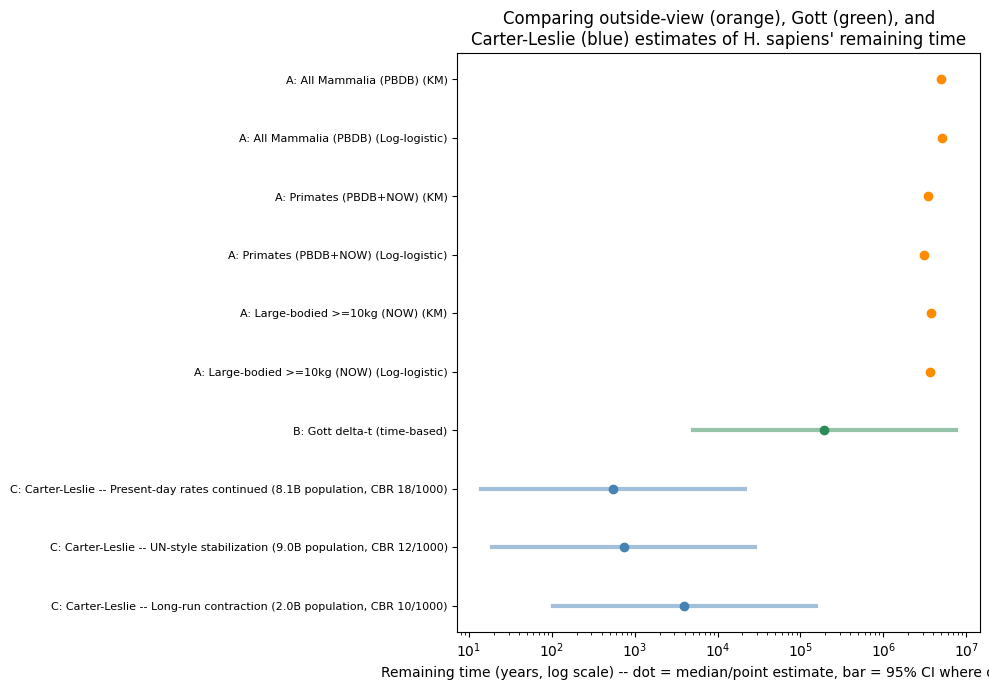

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
labels = synth_df["method"].tolist()
y_pos = np.arange(len(labels))
medians, los, his = synth_df["median_yr"].values, synth_df["lo_yr"].values, synth_df["hi_yr"].values

for i in range(len(labels)):
    color = "darkorange" if labels[i].startswith("A:") else ("seagreen" if labels[i].startswith("B:") else "steelblue")
    ax.plot(medians[i], y_pos[i], "o", color=color)
    if not np.isnan(los[i]):
        ax.plot([los[i], his[i]], [y_pos[i], y_pos[i]], color=color, linewidth=3, alpha=0.5)

ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Remaining time (years, log scale) -- dot = median/point estimate, bar = 95% CI where computed")
ax.set_title("Comparing outside-view (orange), Gott (green), and\nCarter-Leslie (blue) estimates of H. sapiens' remaining time")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("fig4_synthesis_comparison.png", dpi=150)
plt.show()


Two findings stand side by side here:

- **Across methods**, the disagreement remains large and structural (as in
  v1): outside-view (A) and Gott's argument (B) land in the
  hundreds-of-thousands-to-millions-of-years range; Carter-Leslie (C) lands
  in the centuries-to-tens-of-thousands-of-years range once forced through
  any plausible near-term birth rate.
- **Within the outside-view method (A) alone**, narrowing the reference class
  from all-Mammalia to Primates or Large-bodied mammals shifts the estimate
  down by roughly a third to a half -- real and worth taking seriously, but
  small next to the gap between (A)/(B) and (C). Reference-class choice
  matters, but it is not the dominant source of disagreement in this
  notebook; the outside-view/inside-view framing is.


## 6. Pros and cons of this overall approach

*(Summarized and updated from the fuller discussion earlier in this project
thread; v2 changes marked.)*

**General, across all methods**

- *Pro:* Grounds the forecast in either real reference-class data (A) or a
  well-defined self-sampling argument (B, C), giving full distributions
  rather than single numbers.
- *Con:* All three rest on the contested assumption that the present is not a
  privileged point in the relevant sequence (Bostrom 2002).

**Part A (outside view)**

- *Pro:* Uses real, censoring-corrected fossil data from two independent
  databases; **[v2]** narrowing to Primates/Large-bodied partially addresses
  the reference-class-mismatch concern raised in v1, and the fact that both
  narrower classes shift the estimate in the same direction (shorter) by a
  broadly similar amount is a modest reliability signal.
- *Con:* *H. sapiens* remains an outlier even within Primates or
  "large-bodied mammals" on range, population size, interconnectedness, and
  technological buffering. **[v2]** The two data sources have different
  temporal scope (NOW is Cenozoic-only, PBDB spans the whole Phanerozoic),
  different extant/censoring criteria (PBDB has an explicit flag, NOW uses a
  Holocene-cutoff heuristic), and were pooled for the Primates class without
  cross-database deduplication -- all new sources of imprecision introduced
  by this refinement itself. The underlying data still cannot resolve
  timescales below roughly one fossil-dating interval, so all of these
  remain very-long-run, order-of-magnitude statements.

**Part B (Gott delta-t)** -- unchanged from v1: simple and comparison-friendly,
but rests on elapsed time alone and the same contested self-sampling
assumption.

**Part C (Carter-Leslie)** -- unchanged from v1: reuses this project's own
population posterior, but the births-to-years conversion is closer to a
labeled guess than a model, and the answer is highly sensitive to it.


## 7. Conclusions

1. As in v1, three structurally different methods produce answers spanning
   roughly four to five orders of magnitude, and that spread remains the
   headline finding.
2. **New in v2:** restricting the outside-view reference class to Primates or
   to large-bodied mammals specifically lowers the median residual-life
   estimate by roughly 24-40% relative to all-Mammalia, across both the
   Kaplan-Meier and log-logistic priors. This is a real, moderate,
   directionally-consistent effect -- but it is dwarfed by the gap between
   the outside-view/Gott estimates and the Carter-Leslie estimate, so
   reference-class refinement, while worth doing, was not where most of this
   notebook's uncertainty actually lived.
3. Because *H. sapiens*' elapsed existence remains small relative to any of
   the three fitted duration distributions, conditioning on "survived this
   long" still barely moves the outside-view answer relative to the raw
   (unconditional) distribution -- unchanged from v1's finding.
4. None of these estimates should be treated as an actionable forecast. Their
   honest use is as order-of-magnitude anchors and a demonstration of how
   much the answer depends on structural modeling choices -- both which
   "position in history" argument is adopted, and, as v2 now shows
   quantitatively, which reference class is chosen for the outside view.
5. Natural next steps: (a) resolve cross-database duplication between PBDB
   and NOW for the pooled Primates class; (b) apply a consistent
   extant/censoring criterion across both sources rather than PBDB's explicit
   flag vs. NOW's Holocene heuristic; (c) replace the Normal approximation to
   the population posterior in Part C with the actual saved posterior draws;
   (d) explore a hominin-specific (rather than all-Primates) reference class,
   despite the small-sample concerns raised in the earlier literature review.


## 8. References and bibliography

**This project's own prior work**
- `human_population_bayesian_model_v4.ipynb` -- Bayesian model of total
  humans ever born; source of the Part C population posterior.
- `mammal_species_survival_v1.ipynb` -- original (PBDB-only, all-Mammalia)
  derivation of the species-duration priors, with full data-quality
  diagnostics not repeated here.

**Doomsday argument / anthropic reasoning**
- Gott, J.R. III (1993). "Implications of the Copernican principle for our
  future prospects." *Nature*, 363, 315-319.
- Leslie, J. (1996). *The End of the World: The Science and Ethics of Human
  Extinction*. Routledge.
- Carter, B. (1983). "The anthropic principle and its implications for
  biological evolution." *Philosophical Transactions of the Royal Society A*,
  310(1512), 347-363.
- Bostrom, N. (2002). *Anthropic Bias: Observation Selection Effects in
  Science and Philosophy*. Routledge.
- Ord, T. (2020). *The Precipice: Existential Risk and the Future of
  Humanity*. Hachette Books.

**Paleobiological data and methods**
- The Paleobiology Database (PBDB); `taxa/list` API endpoint,
  `base_name=Mammalia`.
- The NOW Community (2021). *New and Old Worlds Database of Fossil Mammals
  (NOW)*. University of Helsinki. https://nowdatabase.org. **[New in v2.]**
- Kaplan, E.L. & Meier, P. (1958). "Nonparametric estimation from incomplete
  observations." *Journal of the American Statistical Association*, 53(282),
  457-481.
- Davidson-Pilon, C. (2019). "lifelines: survival analysis in Python."
  *Journal of Open Source Software*, 4(40), 1317.
- Van Valen, L. (1973). "A new evolutionary law." *Evolutionary Theory*, 1,
  1-30.
- Liow, L.H., Fortelius, M., Bingham, E., Lintulaakso, K., Mannila, H., Flynn,
  L., & Stenseth, N.C. (2008). "Higher origination and extinction rates in
  larger mammals." *Proceedings of the National Academy of Sciences*, 105(16),
  6097-6102. **[New in v2 -- motivates the large-bodied reference class and
  the 10 kg threshold used in Section 2.2.]**
- Hublin, J.-J., et al. (2017). "New fossils from Jebel Irhoud, Morocco and
  the pan-African origin of Homo sapiens." *Nature*, 546, 289-292.
